# Jurkat / 293T mixture: anchor validation and module ablation

Figures with the Jurkat / 293T cell-line mixture as the main data (two cell lines give an unambiguous ground truth for
anchors); both figures also have a human-immune row.

| Figure | Output (`figures/jurkat_293t/`) |
|---|---|
| Anchor precision against recall and coverage, over the number of projections K and the consensus threshold τ | `anchor_validation` |
| Multi-projection consensus against a single projection and against no consensus | `module_ablation` |

Inputs (written by `pipeline/prime_analysis/`): `<out_dir>/anchor_validation/<data set>/anchor_metrics.tsv`,
`<out_dir>/ablation/<data set>/results_task*.tsv` and `<out_dir>/ablation/immune_diag/anchor_type_pairs.tsv`.

A few seconds (result tables only).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

NB_DIR = Path.cwd() if (Path.cwd() / "figlib").is_dir() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_DIR))                 # figlib; it adds pipeline/ and the prime package of this checkout

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from figlib import config, names
from figlib.display import preview, rel, show_png

CFG = config.load()                             # pipeline/config.yaml (+ config.local.yaml)
BENCH = CFG["benchmark"]                        # saved outputs of pipeline/benchmark/
N_JOBS = CFG["n_jobs"]
sc.settings.n_jobs = N_JOBS

In [2]:
# Style and helpers of the analysis figures (figlib/style.py): palette, save, panel, load, sweep, ...
# OUT = out_dir of the pipeline configuration (result tables); figures are written to figures/jurkat_293t/.
import figlib.style as S
from figlib.style import *          # CFG, OUT, C (pipeline/common.py), palette, save, panel, load, sweep, ...
S.set_figure_dir(config.figure_dir("jurkat_293t"))


def draw(fn, name):
    S.apply_style()
    fn()
    png = S.FIG / f"{name}.png"
    if png.exists():
        show_png(png, max_px=1100)
    else:
        print(f"{name}: input tables not found under out_dir; figure skipped")

## Anchor validation

Anchor precision against recall (a, c) and coverage (b, d) for K projections and threshold τ; rows Jurkat / 293T and
human immune.

In [3]:
def fig_anchor_validation():
    """Anchor precision-recall (a, c) and coverage (b, d); rows Jurkat/293T and human immune."""
    fig, axes = plt.subplots(2, 2, figsize=(6.6, 5.2))
    for r, ds in enumerate(("jurkat", "immune")):
        f = OUT / f"anchor_validation/{ds}/anchor_metrics.tsv"
        if not f.exists():
            return
        a = pd.read_csv(f, sep="\t")
        k1 = a[a.K == 1][["precision", "proxy_tpr", "coverage"]].mean()          # K = 1: no consensus
        ax, ax2 = axes[r, 0], axes[r, 1]
        for tau, col in zip((0.3, 0.5, 0.7), SLOT):
            g = a[(a.tau == tau) & (a.K > 1)].groupby("K")[["precision", "proxy_tpr", "coverage"]].mean()
            ax.plot(g["proxy_tpr"], g["precision"], "-o", color=col, label=f"τ = {tau}")
            ax2.plot(g.index, g["coverage"], "-o", color=col, label=f"τ = {tau}")
        ax.scatter([k1["proxy_tpr"]], [k1["precision"]], marker="s", s=22, color=INK, zorder=5, label="K = 1 (no consensus)")
        ax2.scatter([1], [k1["coverage"]], marker="s", s=22, color=INK, zorder=5)
        d = a[(a.K == 4) & (a.tau == 0.4)][["precision", "proxy_tpr", "coverage"]].mean()
        ax.scatter([d["proxy_tpr"]], [d["precision"]], s=55, facecolor="none", edgecolor=INK, lw=1, zorder=5,
                   label="default (K = 4, τ = 0.4)")
        ax2.scatter([4], [d["coverage"]], s=55, facecolor="none", edgecolor=INK, lw=1, zorder=5)
        ax.set_xscale("log")
        ax.set_xlabel("Recall (accepted / all same-type candidate pairs)")
        ax.set_ylabel({"jurkat": "Jurkat/293T", "immune": "Human immune"}[ds] + "\nanchor precision")
        ax.legend(loc="lower left", fontsize=5.5)
        ax.margins(x=0.08, y=0.08)
        panel(ax, "abcd"[2 * r])
        ax2.set_xscale("log")
        ax2.set_yscale("log")
        ax2.set_xlabel("Projections K")
        ax2.set_ylabel("Coverage (cells with ≥1\nsame-type anchor)")
        panel(ax2, "abcd"[2 * r + 1])
    fig.tight_layout()
    save(fig, "anchor_validation")

wrote figures/jurkat_293t/anchor_validation


anchor_validation.png


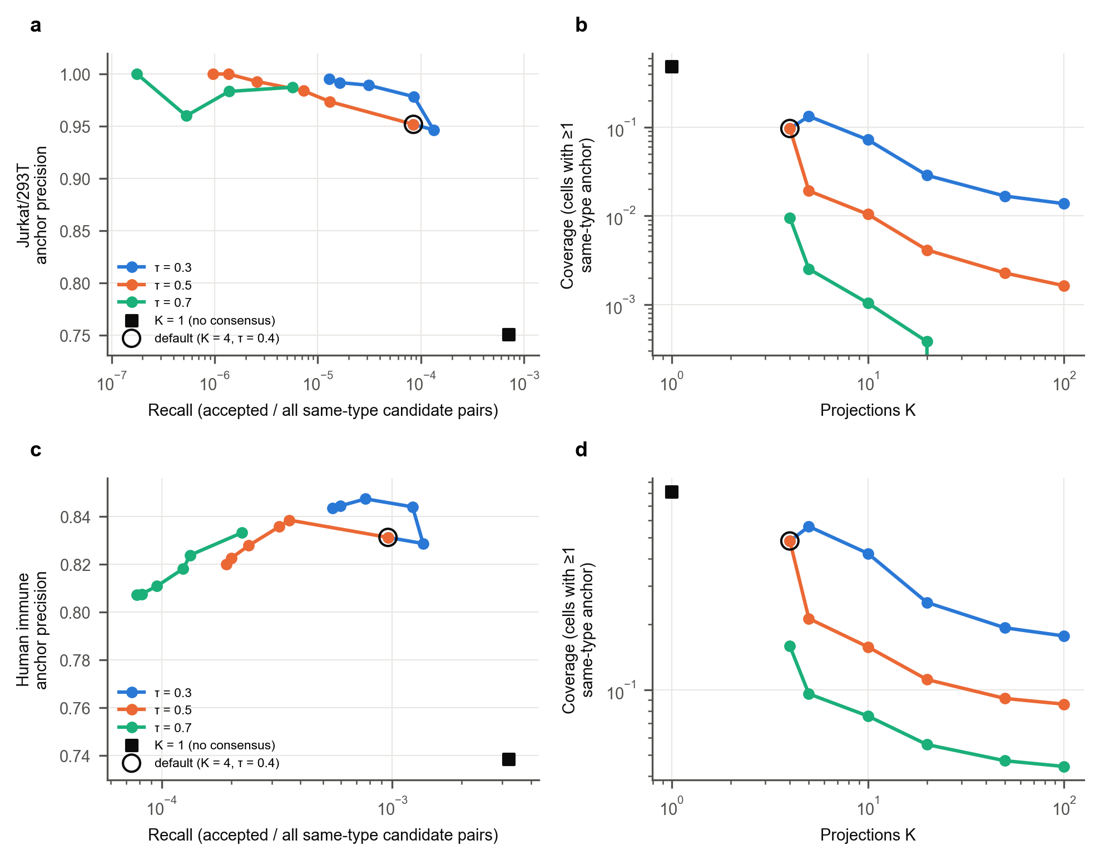

In [4]:
draw(fig_anchor_validation, "anchor_validation")

## Module ablation

The three variants on Jurkat / 293T (a) and human immune (b); anchors joining different cell types on human immune (c).

In [5]:
ABLATION_VARIANTS = [("full", "Multi-projection consensus (PRIME)", SLOT[0], "o"),
               ("single_projection", "Single projection (K = 1)", SLOT[1], "s"),
               ("no_consensus", "No consensus (union of 4 projections)", SLOT[2], "^")]


SHORT = {"CD4+ T cells": "CD4 T", "CD8+ T cells": "CD8 T", "NK cells": "NK", "NKT cells": "NKT",
         "CD14+ Monocytes": "CD14 mono", "CD16+ Monocytes": "CD16 mono", "Monocyte-derived dendritic cells": "moDC",
         "Plasmacytoid dendritic cells": "pDC", "CD20+ B cells": "CD20 B", "CD10+ B cells": "CD10 B"}


def fig_module_ablation():
    """Three variants on Jurkat/293T (a) and human immune (b); wrong anchors per type pair on immune (c)."""
    groups = [("Anchors", [("precision", "Anchor precision"), ("coverage", "Anchor coverage")]),
              ("Batch correction", [("BRAS", "BRAS"), ("iLISI", "iLISI"), ("Graph connectivity", "Graph connectivity")])]
    sets = [(ds, load(f"ablation/{ds}/results_task*.tsv")) for ds in ("jurkat", "immune")]
    pairs = OUT / "ablation/immune_diag/anchor_type_pairs.tsv"
    if any(d is None for _, d in sets) or not pairs.exists():
        return
    rows, y, heads = [], [], []                  # metric rows top to bottom, with a gap between the two groups
    pos = 0.0
    for g, (name, ms) in enumerate(groups):
        pos += 0.55 if g else 0.0
        heads.append((name, pos - 0.5))
        for m in ms:
            rows.append(m); y.append(pos); pos += 1
    y = np.array(y)
    h = 0.26
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.3), gridspec_kw={"width_ratios": [1, 1, 1.05]})
    for n, (ax, (ds, df)) in enumerate(zip(axes[:2], sets)):
        for j, (v, name, col, _) in enumerate(ABLATION_VARIANTS):
            g = df[df.names == v][[m for m, _ in rows]].agg(["mean", "std"])
            yy = y + (j - 1) * h
            ax.barh(yy, g.loc["mean"].values, height=h, color=col, label=name,
                    xerr=g.loc["std"].values, error_kw={"lw": 0.6, "ecolor": INK2, "capsize": 0})
            for yv, mv, sv in zip(yy, g.loc["mean"].values, g.loc["std"].fillna(0).values):
                ax.text(mv + sv + 0.015, yv, f"{mv:.2f}", va="center", fontsize=5.5, color=INK)
        ax.set_yticks(y, [l for _, l in rows] if n == 0 else [])
        ax.tick_params(axis="y", length=0)
        for name, yh in heads:
            ax.axhline(yh - 0.05, color=GRID, lw=0.6) if yh > 0 else None
            if n == 0:
                ax.text(-0.02, yh - 0.12, name, transform=mpl.transforms.blended_transform_factory(ax.transAxes, ax.transData),
                        ha="right", va="center", fontsize=6.5, fontweight="bold", color=INK2)
        ax.set_ylim(y.max() + 0.55, heads[0][1] - 0.3)
        ax.set_xlim(0, 1.12)
        ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
        ax.set_xlabel("Value (mean ± SD, 5 seeds)")
        ax.set_title({"jurkat": "Jurkat/293T", "immune": "Human immune"}[ds])
        ax.grid(axis="y", visible=False)
        panel(ax, "ab"[n])
    p = pd.read_csv(pairs, sep="\t")
    w = p[~p.same].groupby(["variant", "type_a", "type_b"]).n.mean().unstack(0).fillna(0)
    w = w.loc[w["no_consensus"].sort_values(ascending=False).index[:6]]
    ax = axes[2]
    yc = np.arange(len(w))
    for j, (v, name, col, _) in enumerate(ABLATION_VARIANTS):
        ax.barh(yc + (j - 1) * h, w[v].values, height=h, color=col)
    ax.set_yticks(yc, [f"{SHORT.get(a, a)} – {SHORT.get(b, b)}" for a, b in w.index], fontsize=6)
    ax.tick_params(axis="y", length=0)
    ax.set_ylim(len(w) - 0.45, -0.55)
    ax.set_xscale("log")
    ax.set_xlabel("Anchors joining different types (mean of 5 seeds)")
    ax.set_title("Human immune: wrong anchors")
    ax.grid(axis="y", visible=False)
    panel(ax, "c")
    hd, lb = axes[0].get_legend_handles_labels()
    fig.legend(hd, lb, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=6.5, handlelength=1.2)
    fig.tight_layout(w_pad=2.5)
    save(fig, "module_ablation")

wrote figures/jurkat_293t/module_ablation


module_ablation.png


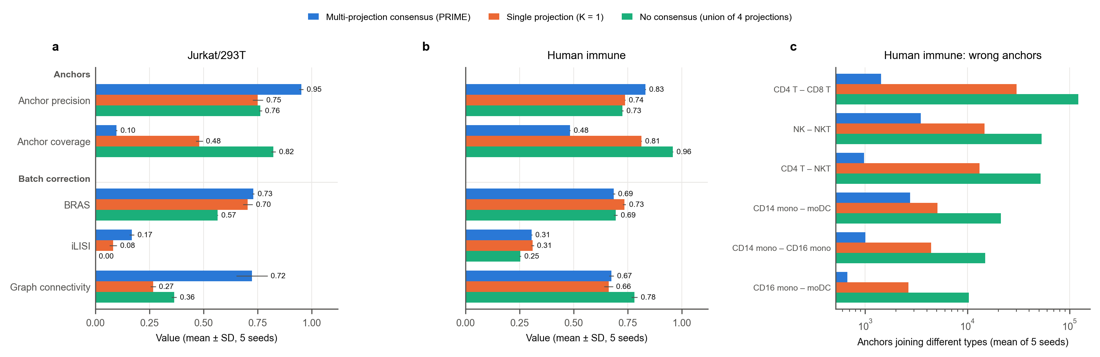

In [6]:
draw(fig_module_ablation, "module_ablation")